
This code is the Python version of the Univserity of Zurich's Matlab files, load.mvnx.m and main_mvnx_adapted.m file, that read Xsens' proprietary ".mvnx" files. 

load.mvnx.m - takes a .mvnx file path and returns a big nested MATLAB struct mvnx containing everything in the file (subject info, segmented definitions, sensor labels, per-frame data, etc.)
* .mvnx files are basically XML and this function is a custom XML parser tailered for the Xsens MVN exports

main_mvnx_adapted.m - is bascially an example script that loads and plots the 2D x, y, z data of time as well as 3D positions of the right hand

In [1]:
# library install imports

%pip install numpy pandas matplotlib nbformat

Note: you may need to restart the kernel to use updated packages.


Load mvnx data

In [2]:
from __future__ import annotations

import os
import re
from typing import Any, Dict, List, Union, Optional
import xml.etree.ElementTree as ET

Number = Union[int, float]
MVNXValue = Union[None, str, Number, List[Number], Dict[str, Any], List[Any]]


# Main function to load MVNX file
def load_mvnx(filepath: str) -> Dict[str, Any]:
    """
    Load an Xsens MVN .mvnx (XML) file into a nested Python structure.

    Namespace handling:
      - XML namespaces are stripped so tags become 'mvnx', 'subject', 'segments', etc.

    Returns:
      {'mvnx': ...}  (root key is always 'mvnx' after namespace stripping)
    """
    path = _normalize_mvnx_path(filepath)
    if not os.path.isfile(path):
        raise FileNotFoundError(f"MVNX file not found: {path}")

    root = ET.parse(path).getroot()
    root_tag = _strip_ns(root.tag)
    return {root_tag: _element_to_obj(root)}


# Helper to normalize MVNX file path
def _normalize_mvnx_path(filepath: str) -> str:
    filepath = filepath.strip().strip('"').strip("'")
    if not filepath.lower().endswith(".mvnx"):
        filepath += ".mvnx"
    return filepath


# Helper to strip namespace from tag
def _strip_ns(tag: str) -> str:
    """Convert '{namespace}tag' -> 'tag'."""
    if "}" in tag:
        return tag.split("}", 1)[1]
    return tag


# Recursive conversion of ElementTree element to Python object
def _element_to_obj(elem: ET.Element) -> MVNXValue:
    """
    Convert an ElementTree element into a Python object (dict / list / scalar),
    while stripping namespaces from element tags (and attribute keys).
    """
    # Attributes (strip namespace in attribute keys too)
    attrs: Dict[str, Any] = {}
    for k, v in (elem.attrib or {}).items():
        attrs[_strip_ns(k)] = _convert_text(v)

    # Children
    children = list(elem)
    if children:
        node: Dict[str, Any] = {}
        node.update(attrs)

        # Group children by (namespace-stripped) tag
        by_tag: Dict[str, List[ET.Element]] = {}
        for child in children:
            by_tag.setdefault(_strip_ns(child.tag), []).append(child)

        for tag, elems in by_tag.items():
            if len(elems) == 1:
                node[tag] = _element_to_obj(elems[0])
            else:
                node[tag] = [_element_to_obj(e) for e in elems]

        # Preserve meaningful mixed text (rare in MVNX)
        text = _strip_or_none(elem.text)
        if text is not None:
            node["text"] = _convert_text(text)

        return node

    # Leaf node
    text = _strip_or_none(elem.text)

    if attrs:
        # If attributes exist, keep them and store text under 'value' if present
        node = dict(attrs)
        if text is not None:
            node["value"] = _convert_text(text)
        return node

    if text is None:
        return None
    return _convert_text(text)


# Helper to strip whitespace or return None
def _strip_or_none(s: Optional[str]) -> Optional[str]:
    if s is None:
        return None
    s2 = s.strip()
    return s2 if s2 != "" else None


_NUM_RE = re.compile(
    r"""^[\s,\[\]]*[-+]?(\d+(\.\d*)?|\.\d+)([eE][-+]?\d+)?([\s,\[\]]+[-+]?(\d+(\.\d*)?|\.\d+)([eE][-+]?\d+)?)*[\s,\[\]]*$"""
)


# Convert text to number(s) if possible
def _convert_text(text: str) -> Union[str, int, float, List[Union[int, float]]]:
    """
    Convert MVNX text content into numbers where possible.
    Handles vectors like "0.1 0.2 0.3" -> [0.1, 0.2, 0.3]
    """
    t = text.strip()

    if _NUM_RE.match(t):
        cleaned = t.replace("[", " ").replace("]", " ").replace(",", " ")
        parts = [p for p in cleaned.split() if p]
        nums: List[Union[int, float]] = []
        for p in parts:
            n = float(p)
            nums.append(int(n) if n.is_integer() else n)
        return nums[0] if len(nums) == 1 else nums

    try:
        if "." in t or "e" in t.lower():
            n = float(t)
            return int(n) if n.is_integer() else n
        return int(t)
    except ValueError:
        return t


# Example utility function to get segment labels
def get_segment_labels(mvnx_dict: Dict[str, Any]) -> List[str]:
    """
    Extract segment labels from:
      mvnx['mvnx']['subject']['segments']['segment']  (list of segment dicts)
    In your data, segments have attributes: 'label' and 'id' (like MATLAB shows).
    """
    mvnx = mvnx_dict["mvnx"]
    segments = mvnx["subject"]["segments"]["segment"]
    if isinstance(segments, dict):  # edge case: only one segment
        segments = [segments]

    return [seg.get("label", "") for seg in segments]


# Example utility function to list available data channels in a frame
def list_frame_channels(mvnx: dict, frame_idx: int = 0):
    frames = mvnx["mvnx"]["subject"]["frames"]["frame"]
    if isinstance(frames, dict):
        frames = [frames]
    frame = frames[frame_idx]
    keys = list(frame.keys()) if isinstance(frame, dict) else []
    return frame.get("type"), keys



Helper function to map segment labels to index to slice in the frame.position, so there's no need to hardcode indices like the Matlab code does for the right hand (31:33).

In [3]:
from __future__ import annotations
from typing import Dict, Any, Tuple, List

def build_segment_index_map(mvnx: Dict[str, Any]) -> Dict[str, int]:
    """
    Returns a dict: {segment_label: zero_based_segment_index}

    Example: {"Pelvis": 0, ..., "RightHand": 10, ...}
    """
    segs = mvnx["mvnx"]["subject"]["segments"]["segment"]
    if isinstance(segs, dict):  # edge case: only one segment
        segs = [segs]

    seg_map: Dict[str, int] = {}
    for i, seg in enumerate(segs):
        label = seg.get("label")
        if isinstance(label, str) and label:
            seg_map[label] = i
    return seg_map


def position_slice_for_segment(
    mvnx: Dict[str, Any],
    segment_label: str,
    *,
    one_based: bool = False
) -> Tuple[int, int]:
    """
    Map segment label -> slice indices for frame.position.

    Returns (start, end_inclusive) if one_based=True (MATLAB-style),
    else returns (start, end_exclusive) for Python slicing.

    Python example:
        start, end = position_slice_for_segment(mvnx, "RightHand")
        xyz = frame["position"][start:end]

    MATLAB equivalence:
        start, end = position_slice_for_segment(mvnx, "RightHand", one_based=True)
        % then position(start:end)
    """
    seg_map = build_segment_index_map(mvnx)
    if segment_label not in seg_map:
        known = ", ".join(sorted(seg_map.keys()))
        raise KeyError(f"Unknown segment '{segment_label}'. Known: {known}")

    seg_idx = seg_map[segment_label]  # 0-based segment index
    start0 = seg_idx * 3
    end0_excl = start0 + 3

    if one_based:
        # Convert Python [start0:end0_excl] to MATLAB start:end (1-based, inclusive)
        return start0 + 1, end0_excl  # end becomes inclusive in 1-based indexing
    return start0, end0_excl


def get_segment_position_xyz(
    mvnx: Dict[str, Any],
    frame: Dict[str, Any],
    segment_label: str
) -> List[float]:
    """
    Convenience: returns [x, y, z] for a segment in a single frame dict.
    """
    start, end = position_slice_for_segment(mvnx, segment_label)
    pos = frame["position"]
    if not isinstance(pos, list) or len(pos) < end:
        raise ValueError("Frame position vector missing or shorter than expected.")
    return pos[start:end]


Reuseable function that takes trajectory extracted and plots x, y, z vs time.

In [4]:
from __future__ import annotations

from typing import Optional, Sequence, Tuple
import numpy as np
import matplotlib.pyplot as plt


def plot_xyz_over_time(
    xyz: Sequence[Sequence[float]],
    *,
    time_s: Optional[Sequence[float]] = None,
    frame_rate_hz: Optional[float] = None,
    title: str = "Position vs Time",
    xlabel: str = "Time (s)",
    ylabel: str = "Position",
    show: bool = True,
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot x, y, z components over time on a single 2D plot.

    Args:
        xyz: Sequence of [x, y, z] samples (N x 3).
        time_s: Optional time vector in seconds (length N).
        frame_rate_hz: If time_s not provided, compute time using t = np.arange(N)/frame_rate_hz.
        title: Plot title.
        xlabel: X-axis label.
        ylabel: Y-axis label.
        show: If True, calls plt.show().

    Returns:
        (fig, ax)
    """
    arr = np.asarray(xyz, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 3:
        raise ValueError(f"xyz must be shape (N, 3). Got {arr.shape}.")

    n = arr.shape[0]

    if time_s is not None:
        t = np.asarray(time_s, dtype=float)
        if t.shape[0] != n:
            raise ValueError(f"time_s must have length {n}. Got {t.shape[0]}.")
    elif frame_rate_hz is not None:
        if frame_rate_hz <= 0:
            raise ValueError("frame_rate_hz must be positive.")
        t = np.arange(n, dtype=float) / float(frame_rate_hz)
    else:
        # fallback: sample index as "time"
        t = np.arange(n, dtype=float)
        xlabel = "Sample index"

    fig, ax = plt.subplots()
    ax.plot(t, arr[:, 0], label="x")
    ax.plot(t, arr[:, 1], label="y")
    ax.plot(t, arr[:, 2], label="z")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()

    if show:
        plt.show()

    return fig, ax


Reusable function that takes trajectory extracted and plots x, y, z using Matplotlib's 3D axes.

In [5]:
from __future__ import annotations

from typing import Optional, Sequence, Tuple
import numpy as np
import matplotlib.pyplot as plt


def plot_xyz_3d(
    xyz: Sequence[Sequence[float]],
    *,
    title: str = "3D Trajectory",
    xlabel: str = "X",
    ylabel: str = "Y",
    zlabel: str = "Z",
    equal_axes: bool = True,
    show: bool = True,
) -> Tuple[plt.Figure, "plt.Axes"]:
    """
    Plot a 3D trajectory from xyz samples (N x 3).

    Args:
        xyz: Sequence of [x, y, z] samples (N x 3).
        title: Plot title.
        xlabel, ylabel, zlabel: Axis labels.
        equal_axes: If True, attempts to set equal scale on x/y/z.
        show: If True, calls plt.show().

    Returns:
        (fig, ax3d)
    """
    arr = np.asarray(xyz, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 3:
        raise ValueError(f"xyz must be shape (N, 3). Got {arr.shape}.")

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(arr[:, 0], arr[:, 1], arr[:, 2])

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_zlabel(zlabel)

    if equal_axes:
        _set_axes_equal_3d(ax, arr)

    if show:
        plt.show()

    return fig, ax


def _set_axes_equal_3d(ax, arr: np.ndarray) -> None:
    """
    Make 3D plot axes have equal scale so the trajectory isn't visually distorted.
    """
    x = arr[:, 0]
    y = arr[:, 1]
    z = arr[:, 2]

    x_min, x_max = np.nanmin(x), np.nanmax(x)
    y_min, y_max = np.nanmin(y), np.nanmax(y)
    z_min, z_max = np.nanmin(z), np.nanmax(z)

    x_range = x_max - x_min
    y_range = y_max - y_min
    z_range = z_max - z_min
    max_range = max(x_range, y_range, z_range)

    # Centers
    x_mid = (x_max + x_min) / 2.0
    y_mid = (y_max + y_min) / 2.0
    z_mid = (z_max + z_min) / 2.0

    half = max_range / 2.0
    ax.set_xlim(x_mid - half, x_mid + half)
    ax.set_ylim(y_mid - half, y_mid + half)
    ax.set_zlim(z_mid - half, z_mid + half)


Main Function

Segment labels: ['Pelvis', 'L5', 'L3', 'T12', 'T8', 'Neck', 'Head', 'RightShoulder', 'RightUpperArm', 'RightForeArm', 'RightHand', 'LeftShoulder', 'LeftUpperArm', 'LeftForeArm', 'LeftHand', 'RightUpperLeg', 'RightLowerLeg', 'RightFoot', 'RightToe', 'LeftUpperLeg', 'LeftLowerLeg', 'LeftFoot', 'LeftToe']
Segment IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
RightHand positions (first 5 frames): [[0.000326, -0.7332, 1.53858], [0.007659, -0.732989, 1.535369], [0.007659, -0.732989, 1.535369], [5.256316, 1.154359, 0.728047], [5.256684, 1.155001, 0.728414]]
normal
Data types: ['time', 'index', 'tc', 'ms', 'type', 'orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 'contacts', 'sensorFreeAcceleration', 'sensorMagneticField', 'sensorOrientation', 'jointAngle', 'jointAngleXZY', 'centerOfMass']


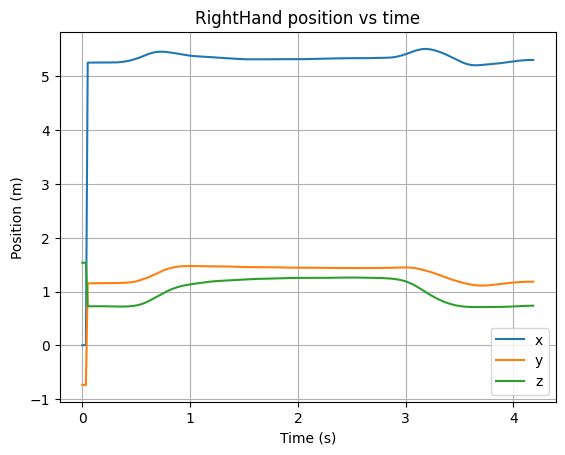

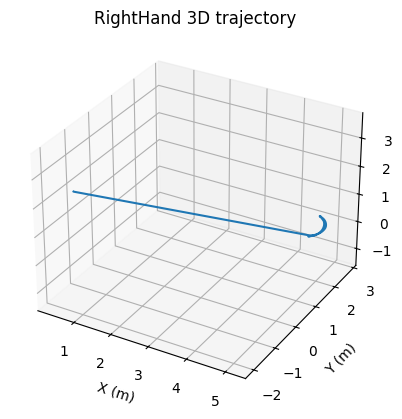

In [ ]:
if __name__ == "__main__":
    m = load_mvnx("ULF_in_ADL/Strokes/P05_SoftProTasks/P05_T10_R2.mvnx")

    # Extract segment labels and IDs
    segments = m["mvnx"]["subject"]["segments"]["segment"]
    labels = [s["label"] for s in segments]
    ids = [s["id"] for s in segments]
    print("Segment labels:", labels[:]) # prints all segment labels
    print("Segment IDs:", ids[:]) # prints all segment IDs

    # Extract RightHand positions over all frames
    frames = m["mvnx"]["subject"]["frames"]["frame"]
    if isinstance(frames, dict):  # edge case: only one frame
        frames = [frames]

    right_hand_xyz = [get_segment_position_xyz(m, fr, "RightHand") for fr in frames]
    print("RightHand positions (first 5 frames):", right_hand_xyz[:5]) # prints the first 5 frames of the right hand positions

    # List available data channels in a frame
    ftype, channels = list_frame_channels(m, frame_idx=3)  # first normal frame in your file
    print(ftype) # normal
    print('Data types:', channels)
    # Results: ['time', 'index', 'tc', 'ms', 'type', 'orientation', 'position', 'velocity', 'acceleration', 'angularVelocity', 'angularAcceleration', 
    # 'contacts', 'sensorFreeAcceleration', 'sensorMagneticField', 'sensorOrientation', 'jointAngle', 'jointAngleXZY', 'centerOfMass']

    xyz = [get_segment_position_xyz(m, fr, "RightHand") for fr in frames]

    # Frame rate is usually here:
    frame_rate = float(m["mvnx"]["subject"].get("frameRate", 0)) or None

    # plot_xyz_over_time(
    #     xyz,
    #     frame_rate_hz=frame_rate,
    #     title="RightHand position vs time",
    #     ylabel="Position (m)"  # MVN is often meters; adjust if your data is different
    # )

    # plot_xyz_3d(
    #     xyz, 
    #     title="RightHand 3D trajectory", 
    #     xlabel="X (m)", 
    #     ylabel="Y (m)", 
    #     zlabel="Z (m)")



In [7]:
segments

[{'label': 'Pelvis',
  'id': 1,
  'points': {'point': [{'label': 'pHipOrigin', 'pos_b': [0, 0, 0]},
    {'label': 'jL5S1', 'pos_b': [-0.000295, 0, 0.122987]},
    {'label': 'jRightHip', 'pos_b': [0.000147, -0.102224, 0.001444]},
    {'label': 'jLeftHip', 'pos_b': [0.000147, 0.102224, 0.001444]},
    {'label': 'pRightSIPS', 'pos_b': [-0.025294, -0.06389, 0.12974]},
    {'label': 'pLeftSIPS', 'pos_b': [-0.025294, 0.06389, 0.12974]},
    {'label': 'pRightASI', 'pos_b': [0.086519, -0.158888, 0.092642]},
    {'label': 'pLeftASI', 'pos_b': [0.086519, 0.158888, 0.092642]},
    {'label': 'pRightCSI', 'pos_b': [0.044751, -0.12778, 0.186814]},
    {'label': 'pLeftCSI', 'pos_b': [0.044751, 0.12778, 0.186814]},
    {'label': 'pRightIschialTub', 'pos_b': [-0.070175, -0.06389, -0.058345]},
    {'label': 'pLeftIschialTub', 'pos_b': [-0.070175, 0.06389, -0.058345]},
    {'label': 'pSacrum', 'pos_b': [-0.086519, 0, 0.033233]},
    {'label': 'pCentralButtock', 'pos_b': [-0.070175, 0, -0.058345]}]}},
 {'